In [333]:
# %pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [334]:
training = pd.read_csv("training_data.csv", encoding="latin1")
test = pd.read_csv("test_data.csv", encoding="latin1")

In [335]:
training.columns

Index(['city_name', 'record_date', 'AVERAGE_SPEED_DIFF',
       'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
       'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY', 'AVERAGE_TEMPERATURE',
       'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED',
       'AVERAGE_CLOUDINESS', 'AVERAGE_PRECIPITATION', 'AVERAGE_RAIN'],
      dtype='object')

In [336]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       4612 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   object 
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       4130 non-null   object 
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             563 non-null    object 
dtypes: float64(8), object(6)

In [337]:
training.head()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,0.0,NaN
1,Porto,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,céu claro,0.0,NaN
2,Porto,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,0.0,NaN
3,Porto,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,céu claro,0.0,NaN
4,Porto,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,0.0,NaN


<Axes: >

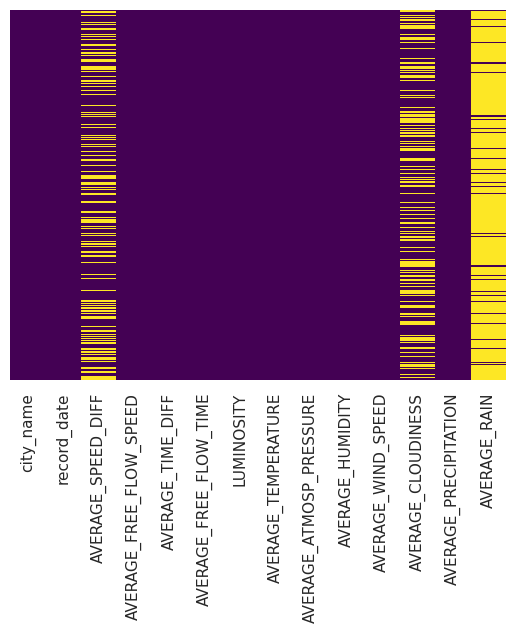

In [338]:
sns.heatmap(training.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [339]:
training.isnull().sum()

city_name                     0
record_date                   0
AVERAGE_SPEED_DIFF         2200
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
AVERAGE_PRECIPITATION         0
AVERAGE_RAIN               6249
dtype: int64

In [340]:
training.nunique()

city_name                     1
record_date                6812
AVERAGE_SPEED_DIFF            4
AVERAGE_FREE_FLOW_SPEED     225
AVERAGE_TIME_DIFF          1151
AVERAGE_FREE_FLOW_TIME      442
LUMINOSITY                    3
AVERAGE_TEMPERATURE          38
AVERAGE_ATMOSP_PRESSURE      43
AVERAGE_HUMIDITY             77
AVERAGE_WIND_SPEED           15
AVERAGE_CLOUDINESS            9
AVERAGE_PRECIPITATION         1
AVERAGE_RAIN                 13
dtype: int64

# *Data pre-processing*

In [341]:
# Dropping unique values

training.drop('city_name', axis=1, inplace=True)
test.drop('city_name', axis=1, inplace=True)

training.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)
test.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)

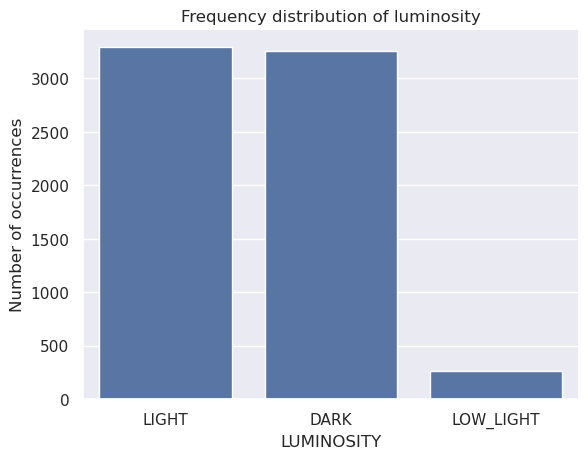

In [342]:
# Handling categorical data ... for LUMINOSITY

lum_count = training['LUMINOSITY'].value_counts()
sns.set(style='darkgrid')
sns.barplot(x=lum_count.index, y=lum_count.values)
plt.title('Frequency distribution of luminosity')
plt.ylabel('Number of occurrences', fontsize=12)
plt.xlabel('LUMINOSITY', fontsize=12)
plt.show()

In [343]:
# Using the factorising technique

training['LUMINOSITY'] = pd.factorize(training['LUMINOSITY'])[0]+1
test['LUMINOSITY'] = pd.factorize(test['LUMINOSITY'])[0]+1

In [344]:
cloudiness_training = pd.get_dummies(training['AVERAGE_CLOUDINESS'], drop_first=True)
cloudiness_test = pd.get_dummies(test['AVERAGE_CLOUDINESS'], drop_first=True)
rain_training = pd.get_dummies(training['AVERAGE_RAIN'], drop_first=True)
rain_test = pd.get_dummies(test['AVERAGE_RAIN'], drop_first=True)

training.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
training = pd.concat([training,cloudiness_training, rain_training], axis=1)

test.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
test = pd.concat([test,cloudiness_test, rain_test], axis=1)

In [345]:
training.head()

,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,...,chuva de intensidade pesada,chuva de intensidade pesado,chuva forte,chuva fraca,chuva leve,chuva moderada,chuvisco e chuva fraca,chuvisco fraco,trovoada com chuva,trovoada com chuva leve
0,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,...,False,False,False,False,False,False,False,False,False,False
1,2018-08-10 14:00:00,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,...,False,False,False,False,False,False,False,False,False,False
2,2019-09-01 16:00:00,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,...,False,False,False,False,False,False,False,False,False,False
3,2019-02-26 11:00:00,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,...,False,False,False,False,False,False,False,False,False,False
4,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,...,False,False,False,False,False,False,False,False,False,False


In [346]:
training = training.dropna(subset=['record_date'])
training['record_date'] = pd.to_datetime(training['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert training['record_date'].isnull().sum() == 0, 'missing record date'
print(training['record_date'].head())

test = test.dropna(subset=['record_date'])
test['record_date'] = pd.to_datetime(test['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert test['record_date'].isnull().sum() == 0, 'missing record date'
print(test['record_date'].head())


0   2019-08-29 07:00:00
1   2018-08-10 14:00:00
2   2019-09-01 16:00:00
3   2019-02-26 11:00:00
4   2019-06-06 12:00:00
Name: record_date, dtype: datetime64[ns]
0   2019-02-13 23:00:00
1   2018-11-28 20:00:00
2   2018-08-14 05:00:00
3   2019-07-06 17:00:00
4   2018-10-15 06:00:00
Name: record_date, dtype: datetime64[ns]


In [347]:
training['record_date_year'] = training['record_date'].dt.year
training['record_date_month'] = training['record_date'].dt.month
training['record_date_day'] = training['record_date'].dt.day
training['record_date_hour'] = training['record_date'].dt.hour
training['record_date_minute'] = training['record_date'].dt.minute
training['record_date_second'] = training['record_date'].dt.second
training.head()

test['record_date_year'] = test['record_date'].dt.year
test['record_date_month'] = test['record_date'].dt.month
test['record_date_day'] = test['record_date'].dt.day
test['record_date_hour'] = test['record_date'].dt.hour
test['record_date_minute'] = test['record_date'].dt.minute
test['record_date_second'] = test['record_date'].dt.second
test.head()

,record_date,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,...,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour,record_date_minute,record_date_second
0,2019-02-13 23:00:00,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,True,...,False,False,False,False,2019,2,13,23,0,0
1,2018-11-28 20:00:00,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,False,...,False,False,False,False,2018,11,28,20,0,0
2,2018-08-14 05:00:00,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,False,...,False,False,False,False,2018,8,14,5,0,0
3,2019-07-06 17:00:00,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,False,...,False,False,False,False,2019,7,6,17,0,0
4,2018-10-15 06:00:00,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,False,...,False,False,False,False,2018,10,15,6,0,0


In [348]:
training.nunique()

record_date                    6812
AVERAGE_SPEED_DIFF                4
AVERAGE_FREE_FLOW_SPEED         225
AVERAGE_TIME_DIFF              1151
AVERAGE_FREE_FLOW_TIME          442
LUMINOSITY                        3
AVERAGE_TEMPERATURE              38
AVERAGE_ATMOSP_PRESSURE          43
AVERAGE_HUMIDITY                 77
AVERAGE_WIND_SPEED               15
céu claro                         2
céu limpo                         2
céu pouco nublado                 2
nublado                           2
nuvens dispersas                  2
nuvens quebradas                  2
nuvens quebrados                  2
tempo nublado                     2
aguaceiros fracos                 2
chuva                             2
chuva de intensidade pesada       2
chuva de intensidade pesado       2
chuva forte                       2
chuva fraca                       2
chuva leve                        2
chuva moderada                    2
chuvisco e chuva fraca            2
chuvisco fraco              

In [349]:
test.nunique()

record_date                1500
AVERAGE_FREE_FLOW_SPEED     199
AVERAGE_TIME_DIFF           610
AVERAGE_FREE_FLOW_TIME      337
LUMINOSITY                    3
AVERAGE_TEMPERATURE          32
AVERAGE_ATMOSP_PRESSURE      42
AVERAGE_HUMIDITY             70
AVERAGE_WIND_SPEED           14
céu claro                     2
céu limpo                     2
céu pouco nublado             2
nublado                       2
nuvens dispersas              2
nuvens quebradas              2
nuvens quebrados              2
tempo nublado                 2
aguaceiros fracos             2
chuva                         2
chuva fraca                   2
chuva leve                    2
chuva moderada                2
chuvisco fraco                2
trovoada com chuva            2
trovoada com chuva leve       2
record_date_year              2
record_date_month            12
record_date_day              31
record_date_hour             24
record_date_minute            1
record_date_second            1
dtype: i

In [350]:
training.isnull().sum()

record_date                       0
AVERAGE_SPEED_DIFF             2200
AVERAGE_FREE_FLOW_SPEED           0
AVERAGE_TIME_DIFF                 0
AVERAGE_FREE_FLOW_TIME            0
LUMINOSITY                        0
AVERAGE_TEMPERATURE               0
AVERAGE_ATMOSP_PRESSURE           0
AVERAGE_HUMIDITY                  0
AVERAGE_WIND_SPEED                0
céu claro                         0
céu limpo                         0
céu pouco nublado                 0
nublado                           0
nuvens dispersas                  0
nuvens quebradas                  0
nuvens quebrados                  0
tempo nublado                     0
aguaceiros fracos                 0
chuva                             0
chuva de intensidade pesada       0
chuva de intensidade pesado       0
chuva forte                       0
chuva fraca                       0
chuva leve                        0
chuva moderada                    0
chuvisco e chuva fraca            0
chuvisco fraco              

In [351]:
# Dropping unique date values

training.drop('record_date_minute', axis=1, inplace=True)
training.drop('record_date_second', axis=1, inplace=True)
training.drop('record_date', axis=1, inplace=True)
#training.dropna(inplace=True)
training.head()

test.drop('record_date_minute', axis=1, inplace=True)
test.drop('record_date_second', axis=1, inplace=True)
test.drop('record_date', axis=1, inplace=True)
test.dropna(inplace=True)
test.head()


,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,céu limpo,...,chuva fraca,chuva leve,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour
0,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,True,False,...,False,False,False,False,False,False,2019,2,13,23
1,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,False,False,...,False,False,False,False,False,False,2018,11,28,20
2,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,False,False,...,False,False,False,False,False,False,2018,8,14,5
3,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,False,False,...,False,False,False,False,False,False,2019,7,6,17
4,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,False,False,...,True,False,False,False,False,False,2018,10,15,6


In [352]:
training.head()

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,...,chuva leve,chuva moderada,chuvisco e chuva fraca,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour
0,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,False,...,False,False,False,False,False,False,2019,8,29,7
1,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,True,...,False,False,False,False,False,False,2018,8,10,14
2,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,False,...,False,False,False,False,False,False,2019,9,1,16
3,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,True,...,False,False,False,False,False,False,2019,2,26,11
4,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,False,...,False,False,False,False,False,False,2019,6,6,12


# *Training model*

In [353]:
# Preparar X_train e y_train
X_train_full = training.drop('AVERAGE_SPEED_DIFF', axis=1)
y_train_full = training['AVERAGE_SPEED_DIFF']

# X_test é o test completo (não tem AVERAGE_SPEED_DIFF)
X_test = test.copy()

print("Antes do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")

# Adicionar colunas que existem no training mas não no test
missing_cols = set(X_train_full.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
    print(f"Adicionada coluna '{col}' ao test")

# Remover colunas que existem no test mas não no training
extra_cols = set(X_test.columns) - set(X_train_full.columns)
if len(extra_cols) > 0:
    X_test.drop(list(extra_cols), axis=1, inplace=True)
    print(f"Removidas {len(extra_cols)} colunas extra do test")

# Reordenar colunas do test para ficarem na mesma ordem que o training
X_test = X_test[X_train_full.columns]

print("\nDepois do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"Colunas coincidem: {list(X_train_full.columns) == list(X_test.columns)}")

Antes do alinhamento:
X_train: (6812, 32)
X_test: (1500, 28)
X_train: (6812, 32)
X_test: (1500, 28)
Adicionada coluna 'chuva de intensidade pesado' ao test
Adicionada coluna 'chuva forte' ao test
Adicionada coluna 'chuva de intensidade pesada' ao test
Adicionada coluna 'chuvisco e chuva fraca' ao test

Depois do alinhamento:
X_train: (6812, 32)
X_test: (1500, 32)
Colunas coincidem: True


In [354]:
y_train_full.fillna("None", inplace=True)

In [355]:
y_train_full.value_counts()

AVERAGE_SPEED_DIFF
None         2200
Medium       1651
Low          1419
High         1063
Very_High     479
Name: count, dtype: int64

In [356]:
mapper = {"None": 0, "Low": 1, "Medium": 2, "High": 3, "Very_High": 4}
y_train_full = y_train_full.map(mapper)
y_train_full.value_counts()

AVERAGE_SPEED_DIFF
0    2200
2    1651
1    1419
3    1063
4     479
Name: count, dtype: int64

# *Random Forest*

In [357]:
from sklearn.model_selection import train_test_split

# Dividir dados para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full,
    test_size=0.3,      # 30% para validação
    random_state=42,
    stratify=y_train_full  # Mantém proporções das classes
)

print(f"\nTreino: {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Test: {X_test.shape}")


Treino: (4768, 32)
Validação: (2044, 32)
Test: (1500, 32)


In [358]:
# Treinar modelo
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [359]:
train_predictions = rf.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
print(f"\nAccuracy no TREINO: {train_accuracy * 100:.2f}%")



Accuracy no TREINO: 100.00%


In [360]:
val_predictions = rf.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)
print(f"Accuracy na VALIDAÇÃO: {val_accuracy * 100:.2f}%")

from sklearn.metrics import classification_report, confusion_matrix

# Classification report
print(classification_report(y_val, val_predictions))

# Confusion matrix
print(confusion_matrix(y_val, val_predictions))

Accuracy na VALIDAÇÃO: 77.69%
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       660
           1       0.67      0.68      0.67       426
           2       0.75      0.74      0.74       495
           3       0.75      0.71      0.73       319
           4       0.87      0.71      0.78       144

    accuracy                           0.78      2044
   macro avg       0.78      0.75      0.76      2044
weighted avg       0.78      0.78      0.78      2044

[[606  54   0   0   0]
 [ 94 289  43   0   0]
 [  7  87 365  36   0]
 [  0   2  76 226  15]
 [  0   0   2  40 102]]


In [361]:
# Treinar modelo com todo o dataset
rf_final = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)

rf_final.fit(X_train_full, y_train_full)

# Fazer previsões no test
test_predictions = rf_final.predict(X_test)

In [362]:
mapper = {0: "None", 1: "Low", 2: "Medium", 3: "High", 4: "Very_High"}
test_predictions = pd.Series(test_predictions).map(mapper)

In [363]:
output = pd.DataFrame({
    'RowId': range(1, len(test_predictions) + 1),
    'Speed_Diff': test_predictions
})
output.to_csv('predictions.csv', index=False)
print("Previsões salvas em 'predictions.csv'")

Previsões salvas em 'predictions.csv'


In [364]:
training.head()

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,...,chuva leve,chuva moderada,chuvisco e chuva fraca,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour
0,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,False,...,False,False,False,False,False,False,2019,8,29,7
1,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,True,...,False,False,False,False,False,False,2018,8,10,14
2,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,False,...,False,False,False,False,False,False,2019,9,1,16
3,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,True,...,False,False,False,False,False,False,2019,2,26,11
4,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,False,...,False,False,False,False,False,False,2019,6,6,12
